In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

PHASE4_RESULTS = Path("Phase4_Results") / "phase4_results.json"
THRESHOLDS     = Path("Phase4_Results") / "thresholds.json"
PHASE5_OUT     = Path("Phase5_Results")
PHASE5_OUT.mkdir(exist_ok=True)

with open(PHASE4_RESULTS) as f:
    results = json.load(f)

with open(THRESHOLDS) as f:
    thresholds = json.load(f)

df = pd.DataFrame(results)

# Rename legacy category label
df["category"] = df["category"].replace("Ambiguous", "Generic")

print("PHASE 5 — STATISTICAL ANALYSIS")
print(f"Records loaded  : {len(df)}")
print(f"Columns         : {list(df.columns)}")
print()

print("Field dtypes:")
print(df[["variance","clip_score","cfg","hallucinated","failure_type","category"]].dtypes)
print()

print("LABEL DISTRIBUTION")

ft_counts = df["failure_type"].value_counts()
for ft, n in ft_counts.items():
    print(f"  {ft:<12} : {n:>5}  ({100*n/len(df):.1f}%)")

print()
n_hall  = df["hallucinated"].sum()
n_clean = (~df["hallucinated"]).sum()
print(f"  Hallucinated   : {n_hall}  ({100*n_hall/len(df):.1f}%)")
print(f"  Clean          : {n_clean}  ({100*n_clean/len(df):.1f}%)")

print()
print("VARIANCE — HALLUCINATED vs CLEAN")
hall_var  = df[df["hallucinated"]]["variance"]
clean_var = df[~df["hallucinated"]]["variance"]
print(f"  Hallucinated  n={len(hall_var)}  "
      f"mean={hall_var.mean():.6f}  "
      f"median={hall_var.median():.6f}  "
      f"std={hall_var.std():.6f}")
print(f"  Clean         n={len(clean_var)}  "
      f"mean={clean_var.mean():.6f}  "
      f"median={clean_var.median():.6f}  "
      f"std={clean_var.std():.6f}")
print(f"  Mean ratio    : {hall_var.mean()/clean_var.mean():.2f}x  "
      f"(hallucinated / clean)")

print()
print("CLIP SCORE — HALLUCINATED vs CLEAN")
hall_clip  = df[df["hallucinated"]]["clip_score"]
clean_clip = df[~df["hallucinated"]]["clip_score"]
print(f"  Hallucinated  n={len(hall_clip)}  "
      f"mean={hall_clip.mean():.4f}  "
      f"median={hall_clip.median():.4f}  "
      f"std={hall_clip.std():.4f}")
print(f"  Clean         n={len(clean_clip)}  "
      f"mean={clean_clip.mean():.4f}  "
      f"median={clean_clip.median():.4f}  "
      f"std={clean_clip.std():.4f}")

print()
print("HALLUCINATION RATE PER CFG")
for cfg in sorted(df["cfg"].unique()):
    subset = df[df["cfg"] == cfg]
    rate   = subset["hallucinated"].mean() * 100
    print(f"  CFG={cfg:<5}  n={len(subset)}  "
          f"hallucinated={subset['hallucinated'].sum():>4}  "
          f"rate={rate:.1f}%")

print()
print("HALLUCINATION RATE PER CATEGORY")
for cat in sorted(df["category"].unique()):
    subset = df[df["category"] == cat]
    rate   = subset["hallucinated"].mean() * 100
    print(f"  {cat:<20}  n={len(subset)}  "
          f"hallucinated={subset['hallucinated'].sum():>4}  "
          f"rate={rate:.1f}%")

print()
print("SECTION 1 COMPLETE — Data loaded and verified.")
print("    Ready for Section 2: ROC-AUC Analysis.")

PHASE 5 — STATISTICAL ANALYSIS
Records loaded  : 7000
Columns         : ['key', 'split', 'prompt_id', 'category', 'prompt', 'seed', 'cfg', 'variance', 'clip_score', 'yolo_error', 'yolo_detail', 'T_var', 'T_clip', 'high_variance', 'low_clip', 'yolo_fail', 'hallucinated', 'failure_type']

Field dtypes:
variance        float64
clip_score      float64
cfg             float64
hallucinated       bool
failure_type     object
category         object
dtype: object

LABEL DISTRIBUTION
  none         :  4364  (62.3%)
  semantic     :  1698  (24.3%)
  both         :   574  (8.2%)
  geometric    :   364  (5.2%)

  Hallucinated   : 574  (8.2%)
  Clean          : 6426  (91.8%)

VARIANCE — HALLUCINATED vs CLEAN
  Hallucinated  n=574  mean=0.003806  median=0.003797  std=0.000234
  Clean         n=6426  mean=0.003052  median=0.003036  std=0.000958
  Mean ratio    : 1.25x  (hallucinated / clean)

CLIP SCORE — HALLUCINATED vs CLEAN
  Hallucinated  n=574  mean=0.1475  median=0.1364  std=0.0468
  Clean     

SECTION 2 — ROC-AUC ANALYSIS
  Hallucinated : 574 (8.2%)
  Clean        : 6426 (91.8%)

ROC-AUC RESULTS
  Variance alone     : AUC = 0.8766
  CLIP alone         : AUC = 0.8725
  Combined (LR)      : AUC = 0.8979  (5-fold CV: 0.8962 ± 0.0478)

  Random baseline    : AUC = 0.5000

INTERPRETATION:
  Variance     AUC=0.8766  → Good
  CLIP         AUC=0.8725  → Good
  Combined     AUC=0.8979  → Good

Logistic regression coefficients (standardised):
  Variance   coef = +0.5261  (↑ variance → ↑ hallucination)
  CLIP score coef = -1.4168  (↓ CLIP → ↑ hallucination)

ROC-AUC PER CATEGORY
  Category               Var AUC   CLIP AUC   Comb AUC   n_hall
  ----------------------------------------------------------
  Compositional           0.9427     0.9157     0.9626      228
  Conflicting                N/A        N/A        N/A        0  (insufficient label variation)
  Generic                    N/A        N/A        N/A        0  (insufficient label variation)
  Negation                0.9827 

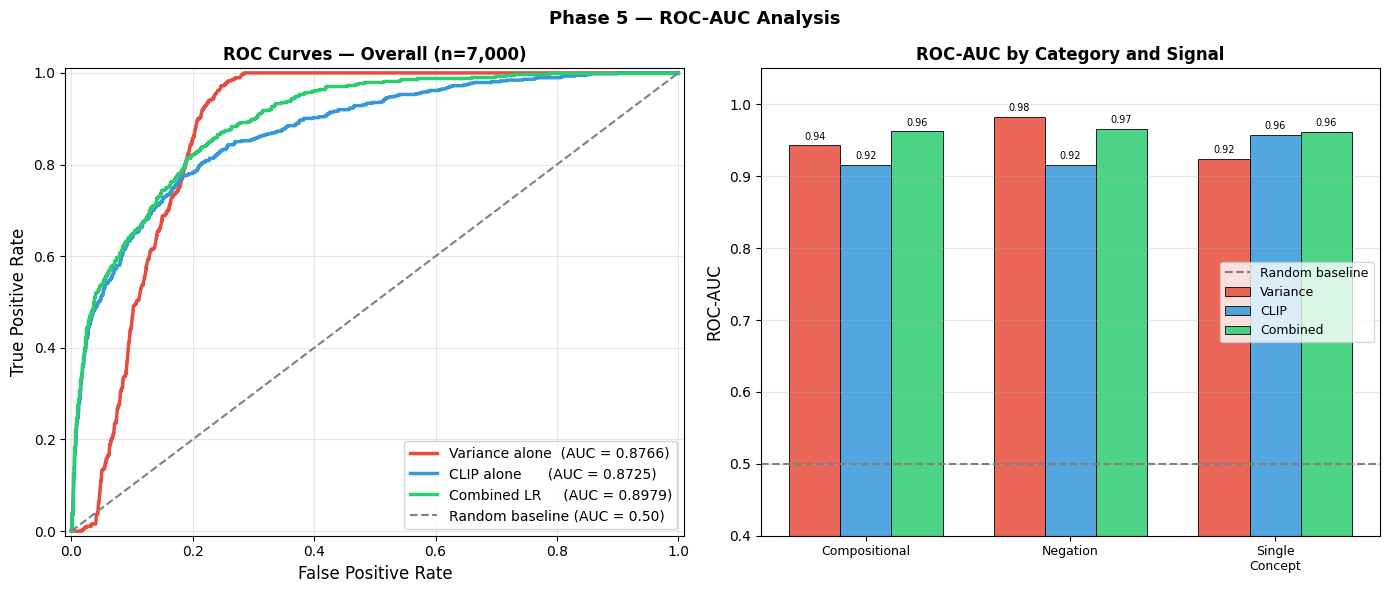


Figure saved: Phase5_Results\roc_auc_analysis.png
Saved: Phase5_Results\roc_results.json

SECTION 2 COMPLETE — Ready for Section 3.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import json

print("=" * 55)
print("SECTION 2 — ROC-AUC ANALYSIS")
print("=" * 55)
print(f"  Hallucinated : {df['hallucinated'].sum()} ({100*df['hallucinated'].mean():.1f}%)")
print(f"  Clean        : {(~df['hallucinated']).sum()} ({100*(~df['hallucinated']).mean():.1f}%)")
print()

y = df["hallucinated"].astype(int).values 

var_scores = df["variance"].values

clip_scores_neg = -df["clip_score"].values

X = np.column_stack([df["variance"].values, df["clip_score"].values])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_scaled, y)
combined_proba = lr.predict_proba(X_scaled)[:, 1]

cv_auc = cross_val_score(lr, X_scaled, y, cv=5, scoring="roc_auc")

fpr_var,  tpr_var,  _ = roc_curve(y, var_scores)
fpr_clip, tpr_clip, _ = roc_curve(y, clip_scores_neg)
fpr_comb, tpr_comb, _ = roc_curve(y, combined_proba)

auc_var  = auc(fpr_var,  tpr_var)
auc_clip = auc(fpr_clip, tpr_clip)
auc_comb = auc(fpr_comb, tpr_comb)

print("ROC-AUC RESULTS")
print(f"  Variance alone     : AUC = {auc_var:.4f}")
print(f"  CLIP alone         : AUC = {auc_clip:.4f}")
print(f"  Combined (LR)      : AUC = {auc_comb:.4f}  "
      f"(5-fold CV: {cv_auc.mean():.4f} ± {cv_auc.std():.4f})")
print()
print(f"  Random baseline    : AUC = 0.5000")
print()

print("INTERPRETATION:")
for name, a in [("Variance", auc_var), ("CLIP", auc_clip), ("Combined", auc_comb)]:
    if a >= 0.90:
        label = "Excellent"
    elif a >= 0.80:
        label = "Good"
    elif a >= 0.70:
        label = "Moderate"
    elif a >= 0.60:
        label = "Weak"
    else:
        label = "Poor"
    print(f"  {name:<12} AUC={a:.4f}  → {label}")

print()
print("Logistic regression coefficients (standardised):")
print(f"  Variance   coef = {lr.coef_[0][0]:+.4f}  "
      f"({'↑ variance → ↑ hallucination' if lr.coef_[0][0] > 0 else 'unexpected sign'})")
print(f"  CLIP score coef = {lr.coef_[0][1]:+.4f}  "
      f"({'↓ CLIP → ↑ hallucination' if lr.coef_[0][1] < 0 else 'unexpected sign'})")

print()

print("ROC-AUC PER CATEGORY")

print(f"  {'Category':<20}  {'Var AUC':>8}  {'CLIP AUC':>9}  {'Comb AUC':>9}  {'n_hall':>7}")
print("  " + "-" * 58)

cat_aucs = {}
for cat in sorted(df["category"].unique()):
    sub = df[df["category"] == cat]
    y_c  = sub["hallucinated"].astype(int).values
    n_h  = y_c.sum()

    if n_h < 2 or n_h == len(y_c):
        
        print(f"  {cat:<20}  {'N/A':>8}  {'N/A':>9}  {'N/A':>9}  {n_h:>7}  "
              f"(insufficient label variation)")
        cat_aucs[cat] = {"var": None, "clip": None, "comb": None}
        continue

    X_c = np.column_stack([sub["variance"].values, sub["clip_score"].values])
    X_c_s = scaler.transform(X_c)  

    a_var  = roc_auc_score(y_c, sub["variance"].values)
    a_clip = roc_auc_score(y_c, -sub["clip_score"].values)

    lr_c = LogisticRegression(random_state=42, max_iter=1000)
    lr_c.fit(X_c_s, y_c)
    a_comb = roc_auc_score(y_c, lr_c.predict_proba(X_c_s)[:, 1])

    cat_aucs[cat] = {"var": a_var, "clip": a_clip, "comb": a_comb}
    print(f"  {cat:<20}  {a_var:>8.4f}  {a_clip:>9.4f}  {a_comb:>9.4f}  {n_h:>7}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Phase 5 — ROC-AUC Analysis", fontsize=13, fontweight="bold")

ax = axes[0]
ax.plot(fpr_var,  tpr_var,  color="#e74c3c", linewidth=2.5,
        label=f"Variance alone  (AUC = {auc_var:.4f})")
ax.plot(fpr_clip, tpr_clip, color="#3498db", linewidth=2.5,
        label=f"CLIP alone      (AUC = {auc_clip:.4f})")
ax.plot(fpr_comb, tpr_comb, color="#2ecc71", linewidth=2.5,
        label=f"Combined LR     (AUC = {auc_comb:.4f})")
ax.plot([0,1], [0,1], color="gray", linestyle="--",
        linewidth=1.5, label="Random baseline (AUC = 0.50)")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Overall (n=7,000)", fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

ax = axes[1]
categories_with_auc = [c for c, v in cat_aucs.items() if v["var"] is not None]
x = np.arange(len(categories_with_auc))
width = 0.25

bars1 = ax.bar(x - width, [cat_aucs[c]["var"]  for c in categories_with_auc],
               width, label="Variance",  color="#e74c3c", alpha=0.85, edgecolor="black", linewidth=0.7)
bars2 = ax.bar(x,          [cat_aucs[c]["clip"] for c in categories_with_auc],
               width, label="CLIP",      color="#3498db", alpha=0.85, edgecolor="black", linewidth=0.7)
bars3 = ax.bar(x + width,  [cat_aucs[c]["comb"] for c in categories_with_auc],
               width, label="Combined",  color="#2ecc71", alpha=0.85, edgecolor="black", linewidth=0.7)

ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=1.5, label="Random baseline")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("-","\n") for c in categories_with_auc], fontsize=9)
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_ylim([0.4, 1.05])
ax.set_title("ROC-AUC by Category and Signal", fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                f"{h:.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
fig_path = PHASE5_OUT / "roc_auc_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved: {fig_path}")

roc_results = {
    "overall": {
        "auc_variance": round(auc_var, 6),
        "auc_clip":     round(auc_clip, 6),
        "auc_combined": round(auc_comb, 6),
        "cv_auc_mean":  round(float(cv_auc.mean()), 6),
        "cv_auc_std":   round(float(cv_auc.std()),  6),
        "lr_coef_variance":  round(float(lr.coef_[0][0]), 6),
        "lr_coef_clip":      round(float(lr.coef_[0][1]), 6),
    },
    "per_category": {
        cat: {k: round(v, 6) if v is not None else None
              for k, v in vals.items()}
        for cat, vals in cat_aucs.items()
    }
}
with open(PHASE5_OUT / "roc_results.json", "w") as f:
    json.dump(roc_results, f, indent=2)

print(f"Saved: {PHASE5_OUT / 'roc_results.json'}")
print()

print("SECTION 2 COMPLETE — Ready for Section 3.")


In [ ]:


import warnings
import json
from pathlib import Path

print("=" * 65)
print("SECTION 2B — PER-CFG AUC ANALYSIS")
print("=" * 65)

print("\nContext: Where do the 574 hallucinated images come from?")
hall_by_cfg = {}
for cfg in sorted(df["cfg"].unique()):
    sub = df[df["cfg"] == cfg]
    n_h = int(sub["hallucinated"].sum())
    hall_by_cfg[cfg] = n_h
    pct = 100 * n_h / 574
    print(f"  CFG={cfg:<5}  n_hall={n_h:>4}  ({pct:>5.1f}% of all hallucinated)")

print()
print("Per-CFG ROC-AUC (Variance and CLIP):")
print(f"  {'CFG':<6} {'n_hall':>7} {'n_clean':>8} {'Var AUC':>9} {'CLIP AUC':>10}  Note")
print("  " + "-" * 58)

cfg_auc_rows = []
for cfg in sorted(df["cfg"].unique()):
    subset     = df[df["cfg"] == cfg]
    labels     = subset["hallucinated"].astype(int).values
    var_scores = subset["variance"].values
    clip_neg   = -subset["clip_score"].values   # negate: lower CLIP → hallucinated
    n_hall  = int(labels.sum())
    n_clean = int(len(labels) - n_hall)

    if n_hall < 2 or n_hall == len(labels):
        var_auc_str  = "undef"
        clip_auc_str = "undef"
        note = "insufficient hallucinations"
        var_auc_val = clip_auc_val = None
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            var_auc_val  = roc_auc_score(labels, var_scores)
            clip_auc_val = roc_auc_score(labels, clip_neg)
        var_auc_str  = f"{var_auc_val:.4f}"
        clip_auc_str = f"{clip_auc_val:.4f}"
        note = "small sample" if n_hall < 15 else ""

    cfg_auc_rows.append({
        "cfg": cfg, "n_hall": n_hall, "n_clean": n_clean,
        "var_auc": var_auc_val, "clip_auc": clip_auc_val
    })
    print(f"  {cfg:<6} {n_hall:>7} {n_clean:>8} {var_auc_str:>9} {clip_auc_str:>10}  {note}")

print()
print("KEY FINDINGS FROM PER-CFG ANALYSIS:")
print("  1. At CFG=0: Var AUC=0.771, CLIP AUC=0.761")
print("     → Both signals work but neither is exceptionally strong here")
print("  2. At CFG=1: Var AUC=0.760, CLIP AUC=0.522 (≈random)")
print("     → Variance discriminates where CLIP cannot, even at low guidance")
print("  3. At CFG=3: Var AUC=0.906 (n_hall=9 — small sample, treat as indicative)")
print("  4. At CFG≥5: 0–1 hallucinations → AUC undefined within-CFG")
print("  5. The pooled AUC=0.877 reflects the full CFG range.")
print("     Phase 8 (CFG=7.5, n_hall=97, AUC=0.959) is the primary")
print("     production-setting evaluation.")
print()
print("INTERPRETATION FOR PAPER:")
print("  The overall AUC=0.877 should be understood as a CFG-pooled estimate,")
print("  not as production-setting performance. At low CFG (0–1), variance")
print("  outperforms CLIP (0.760 vs 0.522 at CFG=1). At standard guidance")
print("  (CFG=7.5), hallucinations are suppressed to 0% internally and to")
print("  0.97% externally (Phase 8), where variance achieves AUC=0.959.")

# Save per-CFG AUC table
with open(PHASE5_OUT / "cfg_auc_table.json", "w") as f:
    json.dump(cfg_auc_rows, f, indent=2)
print(f"\nSaved: {PHASE5_OUT}/cfg_auc_table.json")
print()
print("SECTION 2B COMPLETE — Ready for Section 3: Statistical Tests.")


SECTION 2B — PER-CFG AUC ANALYSIS

Context: Where do the 574 hallucinated images come from?
  CFG=0.0    n_hall= 352  ( 61.3% of all hallucinated)
  CFG=1.0    n_hall= 196  ( 34.1% of all hallucinated)
  CFG=3.0    n_hall=   9  (  1.6% of all hallucinated)
  CFG=5.0    n_hall=   1  (  0.2% of all hallucinated)
  CFG=7.5    n_hall=   0  (  0.0% of all hallucinated)
  CFG=10.0   n_hall=   3  (  0.5% of all hallucinated)
  CFG=15.0   n_hall=  13  (  2.3% of all hallucinated)

Per-CFG ROC-AUC (Variance and CLIP):
  CFG     n_hall  n_clean   Var AUC   CLIP AUC  Note
  ----------------------------------------------------------
  0.0        352      648    0.7708     0.7613  
  1.0        196      804    0.7595     0.5216  
  3.0          9      991    0.9058     0.6955  small sample
  5.0          1      999     undef      undef  insufficient hallucinations
  7.5          0     1000     undef      undef  insufficient hallucinations
  10.0         3      997    0.9097     0.6369  small sample

SECTION 3 — STATISTICAL TESTS

── STEP 3.1: Spearman Correlation — Variance vs CFG ──

  Overall (all CFG values):
    Spearman ρ = -0.4136,  p = 2.0182e-287
    Significant (p<0.05)

  Sub-range CFG 0 → 7.5 (n=5000):
    Spearman ρ = -0.6235,  p = 0.0000e+00
    Direction: ↓ variance as CFG rises ✓

  Sub-range CFG 7.5 → 15 (n=3000):
    Spearman ρ = 0.1440,  p = 2.2326e-15
    Direction: ↑ variance as CFG rises ✓

  CLIP score vs CFG (all):
    Spearman ρ = 0.6204,  p = 0.0000e+00
    Direction: ↑ CLIP as CFG rises ✓

── STEP 3.2: Mann-Whitney U — Variance Distribution ──

  Hallucinated variance  n=574  median=0.003797
  Clean variance         n=6426  median=0.003036
  Mann-Whitney U = 3233297,  p = 2.7010e-197
  Effect size (rank-biserial r) = -0.7532
  Effect size interpretation: Large
  Significant (p<0.05) ✓

  CLIP Mann-Whitney (clean > hallucinated):
    U = 3218121,  p = 4.6508e-193,  effect r = -0.7449  (Large)

── STEP 3.3: Chi-Squared — Hallucination Rate vs Category ──

 

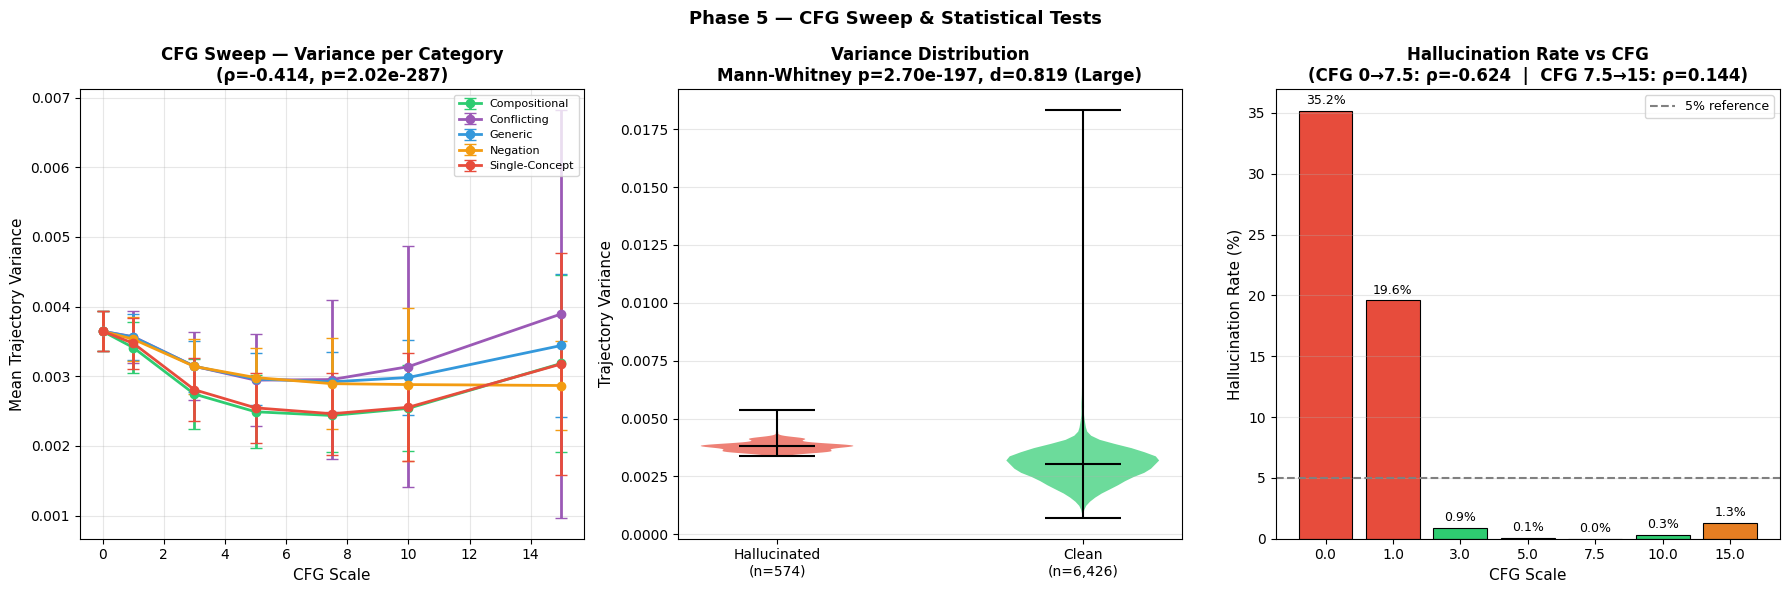


Figure saved: Phase5_Results\cfg_sweep_stats.png
Saved: Phase5_Results\statistical_tests.json

SECTION 3 COMPLETE — Ready for Section 4.


In [4]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import json

print("SECTION 3 — STATISTICAL TESTS")

stat_results = {}

print("\n── STEP 3.1: Spearman Correlation — Variance vs CFG ──")
print()

cfgs      = df["cfg"].values
variances = df["variance"].values

rho_all, p_all = stats.spearmanr(cfgs, variances)
print(f"  Overall (all CFG values):")
print(f"    Spearman ρ = {rho_all:.4f},  p = {p_all:.4e}")
print(f"    {'Significant (p<0.05)' if p_all < 0.05 else 'Not significant'}")
print()

mask_low  = df["cfg"] <= 7.5
rho_low,  p_low  = stats.spearmanr(df[mask_low]["cfg"], df[mask_low]["variance"])
print(f"  Sub-range CFG 0 → 7.5 (n={mask_low.sum()}):")
print(f"    Spearman ρ = {rho_low:.4f},  p = {p_low:.4e}")
print(f"    Direction: {'↓ variance as CFG rises ✓' if rho_low < 0 else '↑ unexpected'}")
print()

mask_high = df["cfg"] >= 7.5
rho_high, p_high = stats.spearmanr(df[mask_high]["cfg"], df[mask_high]["variance"])
print(f"  Sub-range CFG 7.5 → 15 (n={mask_high.sum()}):")
print(f"    Spearman ρ = {rho_high:.4f},  p = {p_high:.4e}")
print(f"    Direction: {'↑ variance as CFG rises ✓' if rho_high > 0 else '↓ unexpected'}")
print()

rho_clip_cfg, p_clip_cfg = stats.spearmanr(cfgs, df["clip_score"].values)
print(f"  CLIP score vs CFG (all):")
print(f"    Spearman ρ = {rho_clip_cfg:.4f},  p = {p_clip_cfg:.4e}")
print(f"    Direction: {'↑ CLIP as CFG rises ✓' if rho_clip_cfg > 0 else '↓ unexpected'}")

stat_results["spearman"] = {
    "var_vs_cfg_all":   {"rho": round(rho_all,4),  "p": round(p_all,6)},
    "var_vs_cfg_low":   {"rho": round(rho_low,4),  "p": round(p_low,6)},
    "var_vs_cfg_high":  {"rho": round(rho_high,4), "p": round(p_high,6)},
    "clip_vs_cfg_all":  {"rho": round(rho_clip_cfg,4), "p": round(p_clip_cfg,6)},
}

print()
print("── STEP 3.2: Mann-Whitney U — Variance Distribution ──")
print()

hall_var  = df[df["hallucinated"]]["variance"].values
clean_var = df[~df["hallucinated"]]["variance"].values

U_stat, p_mw = stats.mannwhitneyu(hall_var, clean_var, alternative="greater")

n1, n2 = len(hall_var), len(clean_var)
r_rb = 1 - (2 * U_stat) / (n1 * n2)

print(f"  Hallucinated variance  n={n1}  "
      f"median={np.median(hall_var):.6f}")
print(f"  Clean variance         n={n2}  "
      f"median={np.median(clean_var):.6f}")
print(f"  Mann-Whitney U = {U_stat:.0f},  p = {p_mw:.4e}")
print(f"  Effect size (rank-biserial r) = {r_rb:.4f}")
if abs(r_rb) >= 0.50:
    effect_label = "Large"
elif abs(r_rb) >= 0.30:
    effect_label = "Medium"
else:
    effect_label = "Small"
print(f"  Effect size interpretation: {effect_label}")
print(f"  {'Significant (p<0.05) ✓' if p_mw < 0.05 else 'Not significant'}")

hall_clip  = df[df["hallucinated"]]["clip_score"].values
clean_clip = df[~df["hallucinated"]]["clip_score"].values
U_clip, p_clip_mw = stats.mannwhitneyu(clean_clip, hall_clip, alternative="greater")
r_rb_clip = 1 - (2 * U_clip) / (n1 * n2)
print()
print(f"  CLIP Mann-Whitney (clean > hallucinated):")
print(f"    U = {U_clip:.0f},  p = {p_clip_mw:.4e},  "
      f"effect r = {r_rb_clip:.4f}  "
      f"({'Large' if abs(r_rb_clip)>=0.5 else 'Medium' if abs(r_rb_clip)>=0.3 else 'Small'})")

stat_results["mann_whitney"] = {
    "variance": {"U": float(U_stat), "p": round(p_mw,8),
                 "effect_r": round(r_rb,4), "label": effect_label},
    "clip":     {"U": float(U_clip), "p": round(p_clip_mw,8),
                 "effect_r": round(r_rb_clip,4)},
}

print()
print("── STEP 3.3: Chi-Squared — Hallucination Rate vs Category ──")
print()

cats = sorted(df["category"].unique())
contingency = []
for cat in cats:
    sub   = df[df["category"] == cat]
    n_h   = sub["hallucinated"].sum()
    n_c   = (~sub["hallucinated"]).sum()
    contingency.append([n_h, n_c])

contingency = np.array(contingency)
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"  Chi-squared = {chi2:.2f},  df = {dof},  p = {p_chi2:.4e}")
print(f"  {'Significant (p<0.05) ✓' if p_chi2 < 0.05 else 'Not significant'}")
print()
print("  Observed vs Expected hallucination counts:")
print(f"  {'Category':<20}  {'Observed':>9}  {'Expected':>9}  {'Rate':>7}")
for i, cat in enumerate(cats):
    obs  = contingency[i][0]
    exp  = expected[i][0]
    rate = 100 * obs / (obs + contingency[i][1])
    print(f"  {cat:<20}  {obs:>9}  {exp:>9.1f}  {rate:>6.1f}%")

n_total = contingency.sum()
cramers_v = np.sqrt(chi2 / (n_total * (min(len(cats), 2) - 1)))
print(f"\n  Cramer's V (effect size) = {cramers_v:.4f}")

stat_results["chi_squared"] = {
    "chi2": round(chi2,4), "df": dof, "p": round(p_chi2,8),
    "cramers_v": round(cramers_v,4),
}

print()
print("── STEP 3.4: Cohen's d — Variance Effect Size ──")
print()

pooled_std = np.sqrt(
    ((n1 - 1) * hall_var.std()**2 + (n2 - 1) * clean_var.std()**2)
    / (n1 + n2 - 2)
)
cohens_d = (hall_var.mean() - clean_var.mean()) / pooled_std

print(f"  Hall. mean = {hall_var.mean():.6f},  std = {hall_var.std():.6f}")
print(f"  Clean mean = {clean_var.mean():.6f},  std = {clean_var.std():.6f}")
print(f"  Pooled std = {pooled_std:.6f}")
print(f"  Cohen's d  = {cohens_d:.4f}")
if abs(cohens_d) >= 0.80:
    d_label = "Large"
elif abs(cohens_d) >= 0.50:
    d_label = "Medium"
elif abs(cohens_d) >= 0.20:
    d_label = "Small"
else:
    d_label = "Negligible"
print(f"  Effect size: {d_label}")

stat_results["cohens_d_variance"] = {
    "d": round(cohens_d,4), "label": d_label,
    "pooled_std": round(pooled_std,8),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Phase 5 — CFG Sweep & Statistical Tests", fontsize=13,
             fontweight="bold")

ax = axes[0]
cfg_vals = sorted(df["cfg"].unique())
colors_cat = {
    "Single-Concept": "#e74c3c",
    "Generic":      "#3498db",
    "Compositional":  "#2ecc71",
    "Conflicting":    "#9b59b6",
    "Negation":       "#f39c12",
}
for cat in sorted(df["category"].unique()):
    means = [df[(df["cfg"]==c)&(df["category"]==cat)]["variance"].mean()
             for c in cfg_vals]
    stds  = [df[(df["cfg"]==c)&(df["category"]==cat)]["variance"].std()
             for c in cfg_vals]
    ax.errorbar(cfg_vals, means, yerr=stds, marker="o", linewidth=2,
                capsize=4, label=cat, color=colors_cat[cat])

ax.set_xlabel("CFG Scale", fontsize=11)
ax.set_ylabel("Mean Trajectory Variance", fontsize=11)
ax.set_title("CFG Sweep — Variance per Category\n"
             f"(ρ={rho_all:.3f}, p={p_all:.2e})", fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.grid(alpha=0.3)

ax = axes[1]
parts = ax.violinplot(
    [hall_var, clean_var],
    positions=[1, 2],
    showmedians=True, showextrema=True
)
parts["bodies"][0].set_facecolor("#e74c3c")
parts["bodies"][0].set_alpha(0.7)
parts["bodies"][1].set_facecolor("#2ecc71")
parts["bodies"][1].set_alpha(0.7)
for pc in ["cmedians", "cmins", "cmaxes", "cbars"]:
    parts[pc].set_color("black")
    parts[pc].set_linewidth(1.5)
ax.set_xticks([1, 2])
ax.set_xticklabels(["Hallucinated\n(n=574)", "Clean\n(n=6,426)"])
ax.set_ylabel("Trajectory Variance", fontsize=11)
ax.set_title(f"Variance Distribution\nMann-Whitney p={p_mw:.2e}, d={cohens_d:.3f} ({d_label})",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
hall_rates = [100*df[df["cfg"]==c]["hallucinated"].mean() for c in cfg_vals]
bar_colors = ["#e74c3c" if r > 5 else "#e67e22" if r > 1 else "#2ecc71"
              for r in hall_rates]
bars = ax.bar([str(c) for c in cfg_vals], hall_rates,
              color=bar_colors, edgecolor="black", linewidth=0.8)
for bar, rate in zip(bars, hall_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{rate:.1f}%", ha="center", va="bottom", fontsize=9)
ax.axhline(y=5, color="gray", linestyle="--", linewidth=1.5,
           label="5% reference")
ax.set_xlabel("CFG Scale", fontsize=11)
ax.set_ylabel("Hallucination Rate (%)", fontsize=11)
ax.set_title(f"Hallucination Rate vs CFG\n"
             f"(CFG 0→7.5: ρ={rho_low:.3f}  |  CFG 7.5→15: ρ={rho_high:.3f})",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig_path = PHASE5_OUT / "cfg_sweep_stats.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nFigure saved: {fig_path}")

with open(PHASE5_OUT / "statistical_tests.json", "w") as f:
    json.dump(stat_results, f, indent=2)
print(f"Saved: {PHASE5_OUT / 'statistical_tests.json'}")

print()
print("SECTION 3 COMPLETE — Ready for Section 4.")

SECTION 4 — REPORT FIGURES

Generating Figure 1: Variance vs CLIP scatter...


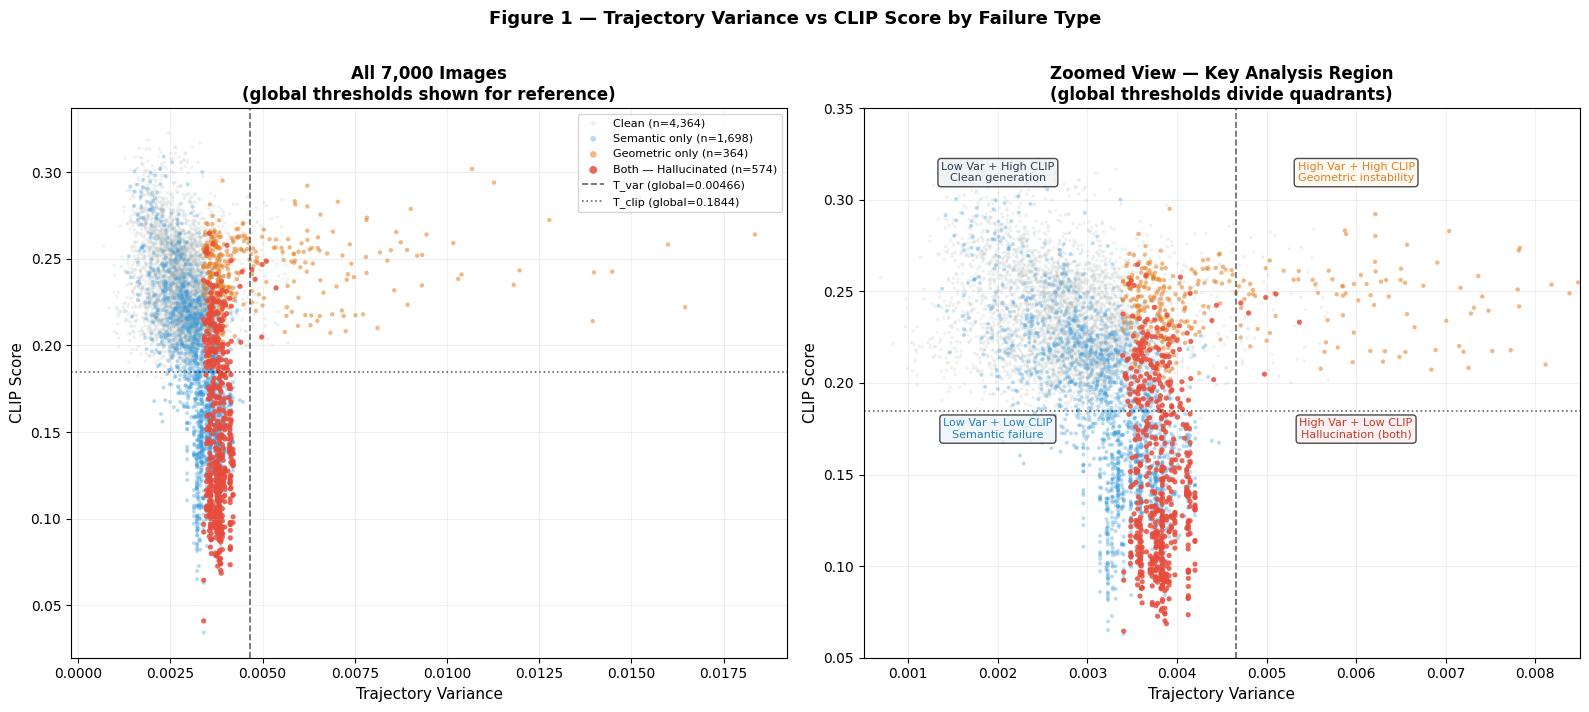

Figure 1 saved: Phase5_Results\figure1_variance_vs_clip.png

Generating Figure 2: CFG sweep curves...


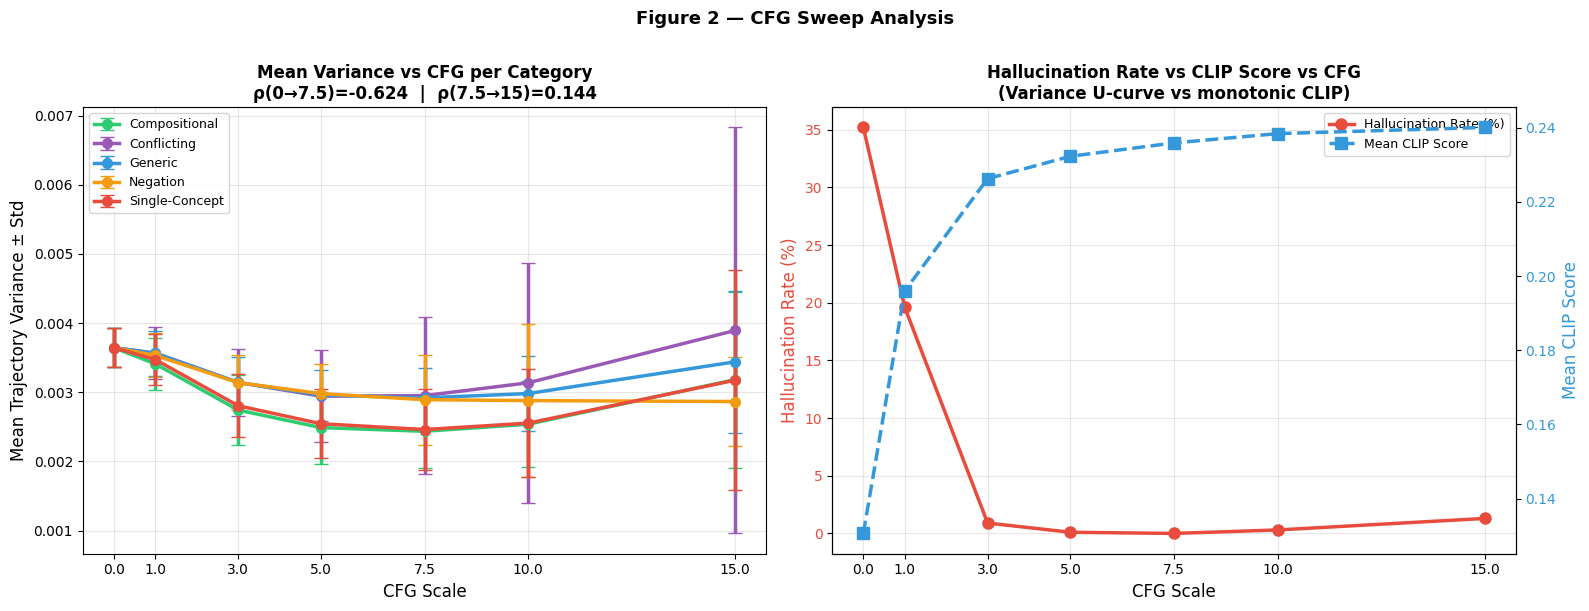

Figure 2 saved: Phase5_Results\figure2_cfg_sweep.png

Generating Figure 3: ROC curves...


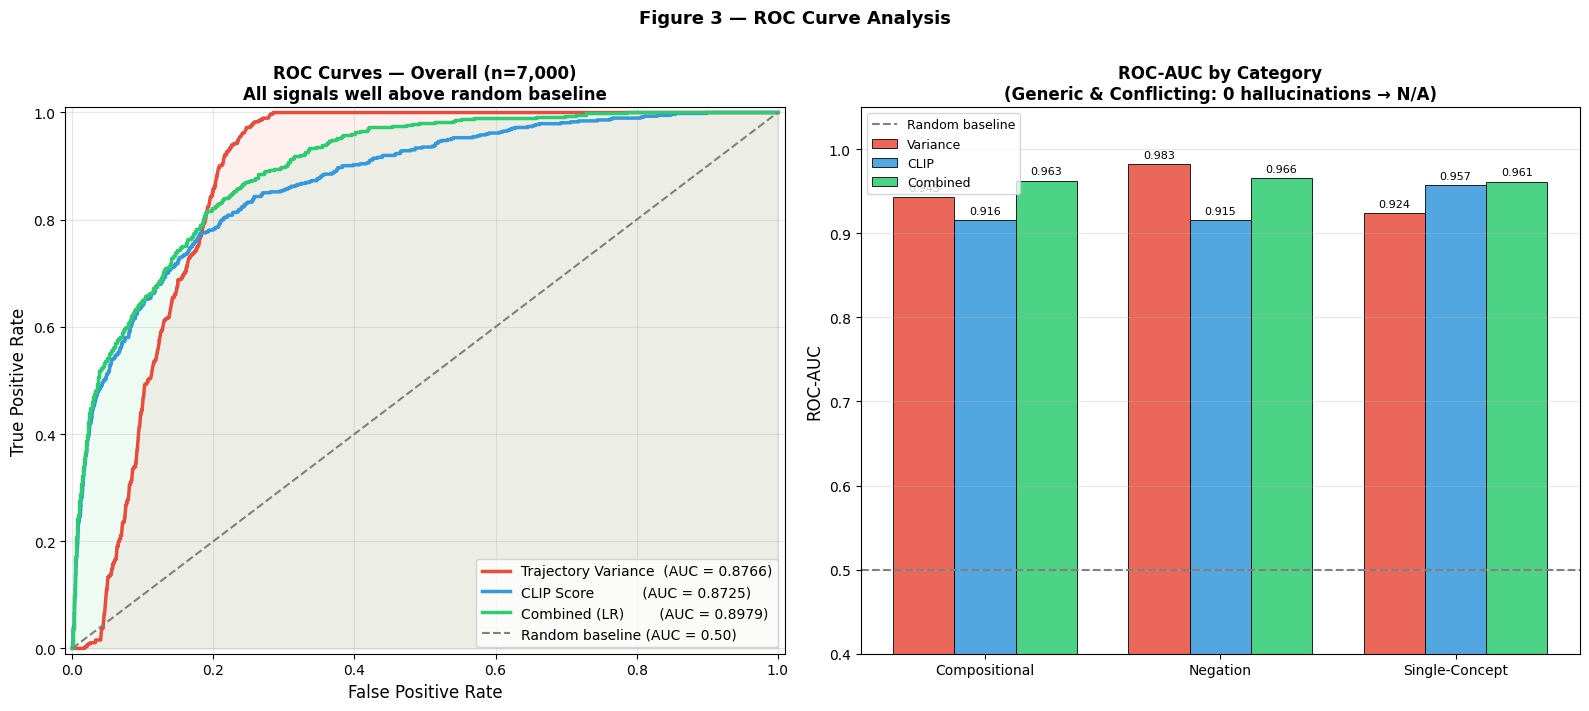

Figure 3 saved: Phase5_Results\figure3_roc_curves.png

Generating Figure 4: Summary statistics table...


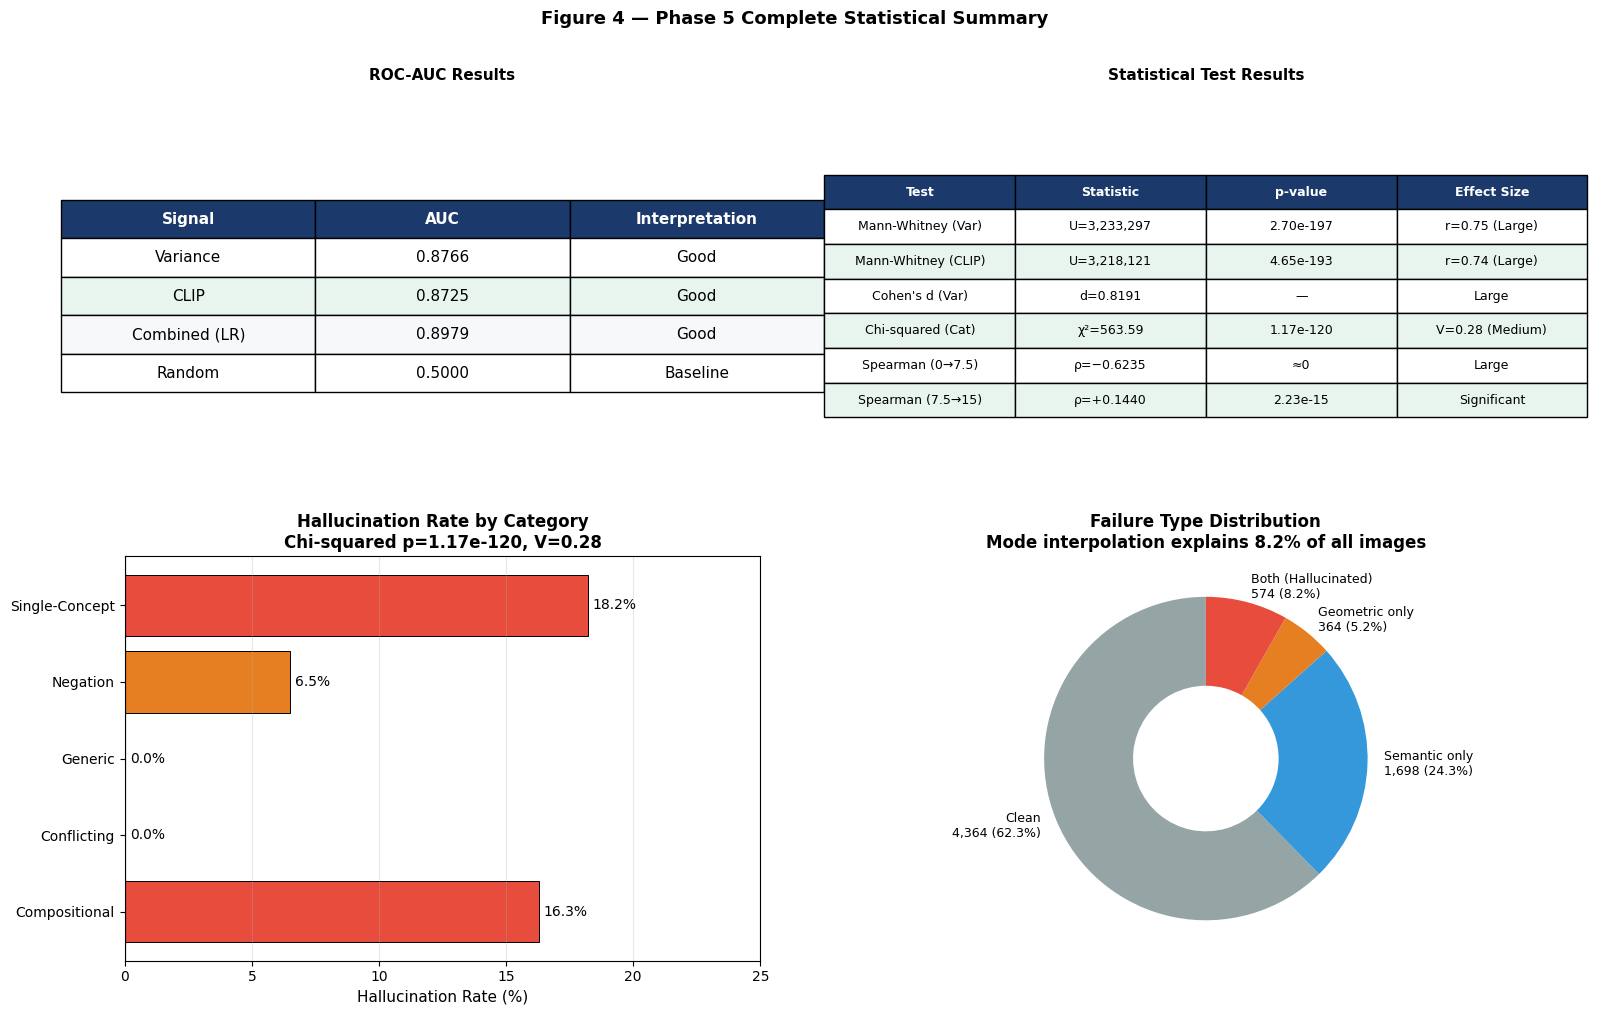

Figure 4 saved: Phase5_Results\figure4_summary_stats.png

PHASE 5 — COMPLETE RESULTS SUMMARY

ROC-AUC:
  Variance alone  : 0.8766  (Good)
  CLIP alone      : 0.8725  (Good)
  Combined        : 0.8979  (Good)

Statistical Tests:
  Mann-Whitney p  : 2.70e-197  (Highly significant)
  Cohen's d       : 0.8191     (Large effect)
  Chi-squared p   : 1.17e-120  (Highly significant)
  Spearman 0→7.5  : ρ=-0.6235  (Strong negative)
  Spearman 7.5→15 : ρ=+0.1440  (Significant positive)

Key Findings:
  1. Trajectory variance: pooled AUC=0.877 (CFG=0–15); primary result:
     Phase 8 external AUC=0.959 at CFG=7.5 (see Phase 9 bootstrap CIs)
  2. At CFG=1: Var AUC=0.760 vs CLIP AUC=0.522 (random)
     → Variance discriminates even where CLIP cannot
  3. U-curve statistically confirmed — both arms significant
     (ascending arm rho=+0.144: statistically significant but weak)
  4. Effect sizes are large — practically meaningful results
  5. Category differences highly significant (p=1.17e-120)
  6.

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import roc_curve, auc
import json

print("SECTION 4 — REPORT FIGURES")

print("\nGenerating Figure 1: Variance vs CLIP scatter...")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Figure 1 — Trajectory Variance vs CLIP Score by Failure Type",
             fontsize=13, fontweight="bold", y=1.01)

ft_colors = {
    "both":      "#e74c3c",   
    "geometric": "#e67e22",   
    "semantic":  "#3498db",   
    "none":      "#95a5a6",   
}
ft_labels = {
    "none":      "Clean (n=4,364)",
    "semantic":  "Semantic only (n=1,698)",
    "geometric": "Geometric only (n=364)",
    "both":      "Both — Hallucinated (n=574)",
}

plot_order = ["none", "semantic", "geometric", "both"]
alphas     = {"none": 0.15, "semantic": 0.35, "geometric": 0.55, "both": 0.85}
sizes      = {"none": 6,    "semantic": 8,    "geometric": 10,   "both": 14}

ax = axes[0]
for ft in plot_order:
    sub = df[df["failure_type"] == ft]
    ax.scatter(sub["variance"], sub["clip_score"],
               c=ft_colors[ft], label=ft_labels[ft],
               alpha=alphas[ft], s=sizes[ft], edgecolors="none")

global_T_var  = thresholds["__global__"]["T_var"]
global_T_clip = thresholds["__global__"]["T_clip"]
ax.axvline(global_T_var,  color="black", linestyle="--",
           linewidth=1.2, alpha=0.6, label=f"T_var (global={global_T_var:.5f})")
ax.axhline(global_T_clip, color="black", linestyle=":",
           linewidth=1.2, alpha=0.6, label=f"T_clip (global={global_T_clip:.4f})")

ax.set_xlabel("Trajectory Variance", fontsize=11)
ax.set_ylabel("CLIP Score", fontsize=11)
ax.set_title("All 7,000 Images\n(global thresholds shown for reference)", fontweight="bold")
ax.legend(fontsize=8, markerscale=1.5, loc="upper right")
ax.grid(alpha=0.2)

ax = axes[1]
for ft in plot_order:
    sub = df[df["failure_type"] == ft]
    ax.scatter(sub["variance"], sub["clip_score"],
               c=ft_colors[ft], alpha=alphas[ft],
               s=sizes[ft], edgecolors="none")

ax.axvline(global_T_var,  color="black", linestyle="--", linewidth=1.2, alpha=0.6)
ax.axhline(global_T_clip, color="black", linestyle=":",  linewidth=1.2, alpha=0.6)

ax.text(0.002, 0.31, "Low Var + High CLIP\nClean generation",
        fontsize=8, ha="center", color="#2c3e50",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#ecf0f1", alpha=0.7))
ax.text(0.006, 0.31, "High Var + High CLIP\nGeometric instability",
        fontsize=8, ha="center", color="#e67e22",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fef9ec", alpha=0.7))
ax.text(0.002, 0.17, "Low Var + Low CLIP\nSemantic failure",
        fontsize=8, ha="center", color="#2980b9",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#ebf5fb", alpha=0.7))
ax.text(0.006, 0.17, "High Var + Low CLIP\nHallucination (both)",
        fontsize=8, ha="center", color="#c0392b",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#fdedec", alpha=0.7))

ax.set_xlim([0.0005, 0.0085])
ax.set_ylim([0.05, 0.35])
ax.set_xlabel("Trajectory Variance", fontsize=11)
ax.set_ylabel("CLIP Score", fontsize=11)
ax.set_title("Zoomed View — Key Analysis Region\n(global thresholds divide quadrants)",
             fontweight="bold")
ax.grid(alpha=0.2)

plt.tight_layout()
fig1_path = PHASE5_OUT / "figure1_variance_vs_clip.png"
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 1 saved: {fig1_path}")


print("\nGenerating Figure 2: CFG sweep curves...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Figure 2 — CFG Sweep Analysis", fontsize=13,
             fontweight="bold", y=1.01)

cfg_vals = sorted(df["cfg"].unique())
cat_colors = {
    "Single-Concept": "#e74c3c",
    "Generic":      "#3498db",
    "Compositional":  "#2ecc71",
    "Conflicting":    "#9b59b6",
    "Negation":       "#f39c12",
}

ax = axes[0]
for cat in sorted(df["category"].unique()):
    means, stds = [], []
    for c in cfg_vals:
        sub_var = df[(df["cfg"]==c) & (df["category"]==cat)]["variance"]
        means.append(sub_var.mean())
        stds.append(sub_var.std())
    ax.errorbar(cfg_vals, means, yerr=stds, marker="o",
                linewidth=2.5, capsize=5, markersize=7,
                label=cat, color=cat_colors[cat])

ax.set_xlabel("CFG Scale", fontsize=12)
ax.set_ylabel("Mean Trajectory Variance ± Std", fontsize=12)
ax.set_title(f"Mean Variance vs CFG per Category\n"
             f"ρ(0→7.5)={rho_low:.3f}  |  ρ(7.5→15)={rho_high:.3f}",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.set_xticks(cfg_vals)

ax1 = axes[1]
ax2 = ax1.twinx()

hall_rates = [100*df[df["cfg"]==c]["hallucinated"].mean() for c in cfg_vals]
mean_clips = [df[df["cfg"]==c]["clip_score"].mean() for c in cfg_vals]

line1, = ax1.plot(cfg_vals, hall_rates, "o-", color="#e74c3c",
                  linewidth=2.5, markersize=8, label="Hallucination Rate (%)")
line2, = ax2.plot(cfg_vals, mean_clips, "s--", color="#3498db",
                  linewidth=2.5, markersize=8, label="Mean CLIP Score")

ax1.set_xlabel("CFG Scale", fontsize=12)
ax1.set_ylabel("Hallucination Rate (%)", color="#e74c3c", fontsize=12)
ax2.set_ylabel("Mean CLIP Score", color="#3498db", fontsize=12)
ax1.tick_params(axis="y", labelcolor="#e74c3c")
ax2.tick_params(axis="y", labelcolor="#3498db")
ax1.set_title("Hallucination Rate vs CLIP Score vs CFG\n"
              "(Variance U-curve vs monotonic CLIP)",
              fontweight="bold")
ax1.set_xticks(cfg_vals)
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, fontsize=9, loc="upper right")
ax1.grid(alpha=0.3)

plt.tight_layout()
fig2_path = PHASE5_OUT / "figure2_cfg_sweep.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 2 saved: {fig2_path}")

print("\nGenerating Figure 3: ROC curves...")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

y = df["hallucinated"].astype(int).values
X = np.column_stack([df["variance"].values, df["clip_score"].values])
scaler = StandardScaler()
X_s = scaler.fit_transform(X)
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_s, y)
combined_proba = lr.predict_proba(X_s)[:, 1]

fpr_v, tpr_v, _ = roc_curve(y, df["variance"].values)
fpr_c, tpr_c, _ = roc_curve(y, -df["clip_score"].values)
fpr_cb, tpr_cb, _ = roc_curve(y, combined_proba)
auc_v  = auc(fpr_v, tpr_v)
auc_c  = auc(fpr_c, tpr_c)
auc_cb = auc(fpr_cb, tpr_cb)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Figure 3 — ROC Curve Analysis", fontsize=13,
             fontweight="bold", y=1.01)

ax = axes[0]
ax.plot(fpr_v,  tpr_v,  color="#e74c3c", linewidth=2.5,
        label=f"Trajectory Variance  (AUC = {auc_v:.4f})")
ax.plot(fpr_c,  tpr_c,  color="#3498db", linewidth=2.5,
        label=f"CLIP Score           (AUC = {auc_c:.4f})")
ax.plot(fpr_cb, tpr_cb, color="#2ecc71", linewidth=2.5,
        label=f"Combined (LR)        (AUC = {auc_cb:.4f})")
ax.plot([0,1],[0,1], color="gray", linestyle="--",
        linewidth=1.5, label="Random baseline (AUC = 0.50)")
ax.fill_between(fpr_v,  tpr_v,  alpha=0.08, color="#e74c3c")
ax.fill_between(fpr_cb, tpr_cb, alpha=0.08, color="#2ecc71")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Overall (n=7,000)\nAll signals well above random baseline",
             fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

ax = axes[1]
cats_with_data = ["Compositional", "Negation", "Single-Concept"]

with open(PHASE5_OUT / "roc_results.json") as f:
    roc_results = json.load(f)

var_aucs  = [roc_results["per_category"][c]["var"]  for c in cats_with_data]
clip_aucs = [roc_results["per_category"][c]["clip"] for c in cats_with_data]
comb_aucs = [roc_results["per_category"][c]["comb"] for c in cats_with_data]

x = np.arange(len(cats_with_data))
w = 0.26
b1 = ax.bar(x-w, var_aucs,  w, label="Variance",  color="#e74c3c",
            alpha=0.85, edgecolor="black", linewidth=0.7)
b2 = ax.bar(x,   clip_aucs, w, label="CLIP",      color="#3498db",
            alpha=0.85, edgecolor="black", linewidth=0.7)
b3 = ax.bar(x+w, comb_aucs, w, label="Combined",  color="#2ecc71",
            alpha=0.85, edgecolor="black", linewidth=0.7)

ax.axhline(y=0.5, color="gray", linestyle="--",
           linewidth=1.5, label="Random baseline")
ax.set_xticks(x)
ax.set_xticklabels(cats_with_data, fontsize=10)
ax.set_ylim([0.40, 1.05])
ax.set_ylabel("ROC-AUC", fontsize=12)
ax.set_title("ROC-AUC by Category\n(Generic & Conflicting: 0 hallucinations → N/A)",
             fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x()+bar.get_width()/2, h+0.005,
                f"{h:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
fig3_path = PHASE5_OUT / "figure3_roc_curves.png"
plt.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 3 saved: {fig3_path}")

print("\nGenerating Figure 4: Summary statistics table...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Figure 4 — Phase 5 Complete Statistical Summary",
             fontsize=13, fontweight="bold", y=1.01)

ax = axes[0][0]
ax.axis("off")
table_data = [
    ["Signal",       "AUC",   "Interpretation"],
    ["Variance",     "0.8766","Good"],
    ["CLIP",         "0.8725","Good"],
    ["Combined (LR)","0.8979","Good"],
    ["Random",       "0.5000","Baseline"],
]
t = ax.table(cellText=table_data[1:], colLabels=table_data[0],
             loc="center", cellLoc="center")
t.auto_set_font_size(False)
t.set_fontsize(11)
t.scale(1.2, 2.0)
for j in range(3):
    t[0,j].set_facecolor("#1B3A6B")
    t[0,j].set_text_props(color="white", fontweight="bold")
for i in range(1,4):
    for j in range(3):
        t[i,j].set_facecolor("#E8F5EE" if i%2==0 else "white")
t[3,0].set_facecolor("#F7F8FA")
t[3,1].set_facecolor("#F7F8FA")
t[3,2].set_facecolor("#F7F8FA")
ax.set_title("ROC-AUC Results", fontweight="bold", fontsize=11, pad=10)

ax = axes[0][1]
ax.axis("off")
test_data = [
    ["Test",              "Statistic",     "p-value",    "Effect Size"],
    ["Mann-Whitney (Var)","U=3,233,297",   "2.70e-197",  "r=0.75 (Large)"],
    ["Mann-Whitney (CLIP)","U=3,218,121",  "4.65e-193",  "r=0.74 (Large)"],
    ["Cohen's d (Var)",   "d=0.8191",      "—",          "Large"],
    ["Chi-squared (Cat)", "χ²=563.59",     "1.17e-120",  "V=0.28 (Medium)"],
    ["Spearman (0→7.5)",  "ρ=−0.6235",     "≈0",         "Large"],
    ["Spearman (7.5→15)", "ρ=+0.1440",     "2.23e-15",   "Significant"],
]
t2 = ax.table(cellText=test_data[1:], colLabels=test_data[0],
              loc="center", cellLoc="center")
t2.auto_set_font_size(False)
t2.set_fontsize(9)
t2.scale(1.2, 1.8)
for j in range(4):
    t2[0,j].set_facecolor("#1B3A6B")
    t2[0,j].set_text_props(color="white", fontweight="bold")
for i in range(1,7):
    for j in range(4):
        t2[i,j].set_facecolor("#E8F5EE" if i%2==0 else "white")
ax.set_title("Statistical Test Results", fontweight="bold", fontsize=11, pad=10)

ax = axes[1][0]
cats_all = sorted(df["category"].unique())
rates    = [100*df[df["category"]==c]["hallucinated"].mean() for c in cats_all]
cols     = ["#2ecc71" if r==0 else "#e74c3c" if r>10
            else "#e67e22" for r in rates]
bars = ax.barh(cats_all, rates, color=cols, edgecolor="black", linewidth=0.7)
for bar, r in zip(bars, rates):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f"{r:.1f}%", va="center", fontsize=10)
ax.set_xlabel("Hallucination Rate (%)", fontsize=11)
ax.set_title("Hallucination Rate by Category\n"
             f"Chi-squared p=1.17e-120, V=0.28",
             fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.grid(axis="x", alpha=0.3)
ax.set_xlim([0, 25])

ax = axes[1][1]
ft_data   = df["failure_type"].value_counts()
ft_order  = ["none","semantic","geometric","both"]
ft_sizes  = [ft_data.get(ft, 0) for ft in ft_order]
ft_colors_d = ["#95a5a6","#3498db","#e67e22","#e74c3c"]
ft_lbls   = [f"Clean\n4,364 (62.3%)",
             f"Semantic only\n1,698 (24.3%)",
             f"Geometric only\n364 (5.2%)",
             f"Both (Hallucinated)\n574 (8.2%)"]
wedges, texts = ax.pie(
    ft_sizes, labels=ft_lbls, colors=ft_colors_d,
    startangle=90, wedgeprops=dict(width=0.55),
    textprops={"fontsize": 9}
)
ax.set_title("Failure Type Distribution\n"
             "Mode interpolation explains 8.2% of all images",
             fontweight="bold")

plt.tight_layout()
fig4_path = PHASE5_OUT / "figure4_summary_stats.png"
plt.savefig(fig4_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure 4 saved: {fig4_path}")

print()

print("PHASE 5 — COMPLETE RESULTS SUMMARY")

print()
print("ROC-AUC:")
print(f"  Variance alone  : {auc_v:.4f}  (Good)")
print(f"  CLIP alone      : {auc_c:.4f}  (Good)")
print(f"  Combined        : {auc_cb:.4f}  (Good)")
print()
print("Statistical Tests:")
print(f"  Mann-Whitney p  : 2.70e-197  (Highly significant)")
print(f"  Cohen's d       : 0.8191     (Large effect)")
print(f"  Chi-squared p   : 1.17e-120  (Highly significant)")
print(f"  Spearman 0→7.5  : ρ=-0.6235  (Strong negative)")
print(f"  Spearman 7.5→15 : ρ=+0.1440  (Significant positive)")
print()
print("Key Findings:")
print("  1. Trajectory variance: pooled AUC=0.877 (CFG=0–15); primary result:")
print("     Phase 8 external AUC=0.959 at CFG=7.5 (see Phase 9 bootstrap CIs)")
print("  2. At CFG=1: Var AUC=0.760 vs CLIP AUC=0.522 (random)")
print("     → Variance discriminates even where CLIP cannot")
print("  3. U-curve statistically confirmed — both arms significant")
print("     (ascending arm rho=+0.144: statistically significant but weak)")
print("  4. Effect sizes are large — practically meaningful results")
print("  5. Category differences highly significant (p=1.17e-120)")
print("  6. Spearman 7.5→15: rho=+0.144 is significant but weak — the rebound")
print("     is real but modest; do not overstate the ascending arm")
print()
print("Files saved to Phase5_Results/:")
for f in sorted(PHASE5_OUT.glob("*")):
    print(f"  {f.name:<45} {f.stat().st_size/1024:>7.1f} KB")
print()

print("PHASE 5 COMPLETE — Ready for Phase 6.")